In [728]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

# --- LOAD DATA ---
df = pd.read_csv("patient.csv")

## Preprocessing

In [729]:
df.head()

,ชื่อกลุ่มโรค,อายุ (เต็ม) ปี,อายุ (เต็ม) เดือน,อาย (เต็ม) วัน,เพศ,สถานภาพสมรส,สัญชาติ,อาชีพ,จังหวัด,อำเภอ/เขต,ตำบล/แขวง,วันที่เริ่มป่วย,สภาพผู้ป่วย,ประเภทผู้ป่วย,สถานที่รักษา
0,ไข้เลือดออก,39,9.0,2.0,ชาย,โสด,ไทย,รับจ้าง,กรุงเทพมหานคร,บางขุนเทียน,แสมดำ,1/1/2026,ยังรักษาอยู่,ผู้ป่วยใน,โรงพยาบาลบางปะกอก 8 โรงพยาบาลทั่วไปขนาดใหญ่
1,ไข้เลือดออก,10,2.0,0.0,ชาย,โสด,ไทย,ไม่ระบุ,กรุงเทพมหานคร,ดินแดง,ดินแดง,1/1/2026,ยังรักษาอยู่,ผู้ป่วยใน,โรงพยาบาลลาดพร้าว
2,ไข้เลือดออก,6,2.0,27.0,ชาย,โสด,ไทย,ไม่ระบุ,กรุงเทพมหานคร,พระโขนง,บางจาก,1/1/2026,ยังรักษาอยู่,ผู้ป่วยใน,โรงพยาบาลหัวเฉียวโรงพยาบาลทั่วไปขนาดใหญ่
3,ไข้เลือดออก,42,0.0,27.0,ชาย,โสด,ไทย,ไม่ระบุ,กรุงเทพมหานคร,คลองสาน,คลองต้นไทร,1/1/2026,ไม่ทราบ,ผู้ป่วยนอก,โรงพยาบาลหัวเฉียวโรงพยาบาลทั่วไปขนาดใหญ่
4,ไข้เลือดออก,8,8.0,12.0,ชาย,โสด,ไทย,ไม่ทราบ / ไม่ระบุ,กรุงเทพมหานคร,ทวีวัฒนา,ศาลาธรรมสพน์,1/1/2026,ไม่ทราบ,ผู้ป่วยนอก,โรงพยาบาลราชพิพัฒน์


In [730]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59920 entries, 0 to 59919
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ชื่อกลุ่มโรค       59920 non-null  object 
 1   อายุ (เต็ม) ปี     59920 non-null  int64  
 2   อายุ (เต็ม) เดือน  59919 non-null  float64
 3   อาย (เต็ม) วัน     59917 non-null  float64
 4   เพศ                59920 non-null  object 
 5   สถานภาพสมรส        59920 non-null  object 
 6   สัญชาติ            59920 non-null  object 
 7   อาชีพ              59917 non-null  object 
 8   จังหวัด            59920 non-null  object 
 9   อำเภอ/เขต          59920 non-null  object 
 10  ตำบล/แขวง          59920 non-null  object 
 11  วันที่เริ่มป่วย    59920 non-null  object 
 12  สภาพผู้ป่วย        59920 non-null  object 
 13  ประเภทผู้ป่วย      59920 non-null  object 
 14  สถานที่รักษา       59920 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 6.9+ MB


In [731]:
df.describe()

,อายุ (เต็ม) ปี,อายุ (เต็ม) เดือน,อาย (เต็ม) วัน
count,59920.000000,59919.000000,59917.000000
mean,31.558311,3.324371,9.039738
std,22.502255,3.758181,11.463461
min,0.000000,0.000000,0.000000
25%,11.000000,0.000000,0.000000
50%,30.000000,2.000000,5.000000
75%,45.000000,6.000000,17.000000
max,108.000000,27.000000,364.000000


C:\Users\thanyathorn\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thanyathorn\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thanyathorn\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thanyathorn\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\thanyathorn\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabto

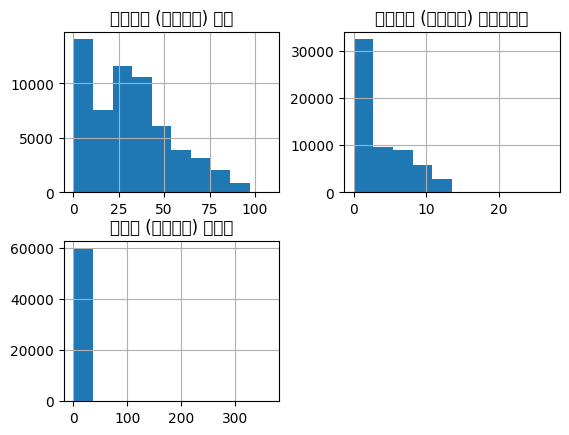

In [732]:
df.hist()
plt.show()

### Data Cleaning

In [733]:
column_mapping = {
    "ชื่อกลุ่มโรค": "disease_type",
    "อายุ (เต็ม) ปี": "ageyear",
    "อายุ (เต็ม) เดือน": "agemonth",
    "อาย (เต็ม) วัน": "ageday",
    "เพศ": "sex",
    "สถานภาพสมรส": "marital_status",
    "สัญชาติ": "nationality",
    "อาชีพ": "occupation",
    "จังหวัด": "province",
    "อำเภอ/เขต": "district",
    "ตำบล/แขวง": "sub_district",
    "วันที่เริ่มป่วย": "date_disease_start",
    "สภาพผู้ป่วย": "patient_status",
    "ประเภทผู้ป่วย": "patient_type",
    "สถานที่รักษา": "hospital_name"
}
df = df.rename(columns=column_mapping)
print(df.columns)

Index(['disease_type', 'ageyear', 'agemonth', 'ageday', 'sex',
       'marital_status', 'nationality', 'occupation', 'province', 'district',
       'sub_district', 'date_disease_start', 'patient_status', 'patient_type',
       'hospital_name'],
      dtype='object')


In [734]:
df.tail() #OK, the column name change!

,disease_type,ageyear,agemonth,ageday,sex,marital_status,nationality,occupation,province,district,sub_district,date_disease_start,patient_status,patient_type,hospital_name
59915,อุจจาระร่วง,36,2.0,13.0,หญิง,โสด,ไทย,ไม่ทราบ / ไม่ระบุ,กรุงเทพมหานคร,จตุจักร,จตุจักร,30/3/2026,ยังรักษาอยู่,ผู้ป่วยใน,โรงพยาบาลวิมุตโรงพยาบาลทั่วไปขนาดใหญ่
59916,อุจจาระร่วง,69,3.0,13.0,หญิง,คู่,ไทย,ไม่ระบุ,กรุงเทพมหานคร,จอมทอง,บางมด,30/3/2026,ไม่ทราบ,ผู้ป่วยนอก,โรงพยาบาลนครธน
59917,อุจจาระร่วง,65,2.0,30.0,ชาย,คู่,ไทย,รับจ้าง,กรุงเทพมหานคร,หนองจอก,คลองสิบ,30/3/2026,ไม่ทราบ,ผู้ป่วยนอก,โรงพยาบาลเวชการุณย์รัศมิ์
59918,อุจจาระร่วง,69,4.0,29.0,หญิง,โสด,ไทย,ค้าขาย,กรุงเทพมหานคร,ยานนาวา,บางโพงพาง,31/3/2026,ยังรักษาอยู่,ผู้ป่วยนอก,โรงพยาบาลเจริญกรุงประชารักษ์
59919,ไข้หวัดใหญ่,23,0.0,0.0,ชาย,โสด,ไทย,ไม่ทราบ / ไม่ระบุ,กรุงเทพมหานคร,ภาษีเจริญ,บางหว้า,31/3/2026,ยังรักษาอยู่,ผู้ป่วยนอก,ศูนย์บริการสาธารณสุข 26 เจ้าคุณพระประยูรวงศ์


In [735]:
#CHANGE THE AGE
# handle missing values first
df[["ageyear", "agemonth", "ageday"]] = df[
    ["ageyear", "agemonth", "ageday"]
].fillna(0)

# create new age column (decimal years)
df["age"] = (
    df["ageyear"] +
    df["agemonth"] / 12 +
    df["ageday"] / 365
)

# check result
print(df[["ageyear", "agemonth", "ageday", "age"]].head())
df = df.drop(columns=["ageyear", "agemonth", "ageday"]) #Remove the ageyear,month,day

   ageyear  agemonth  ageday        age
0       39       9.0     2.0  39.755479
1       10       2.0     0.0  10.166667
2        6       2.0    27.0   6.240639
3       42       0.0    27.0  42.073973
4        8       8.0    12.0   8.699543


In [736]:
categorical_cols = [
    "disease_type",
    "sex",
    "marital_status",
    "nationality",
    "occupation",
    "province",
    "district",
    "sub_district",
    "patient_status",
    "patient_type",
    "hospital_name"
]

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())

df.nunique() #conclusion of how many category in one column

#We know that there are 4 disease
#Male = 34111
#Female = 25809
#Single = 35661, Marriage = 7219 Is Marriage status increase the chance of infection??
#Occupation misses a lot data (more than half is Unknown/Not specified)
#Province: Bangkok
#District: 50 District as usual
#Subdistrict: This may be too much detailed
#Patient Status: Irrelevant?
#Patient_type: Irrelevant?
#hospital_name: Irrelevant?


Column: disease_type
disease_type
อุจจาระร่วง            34255
ไข้หวัดใหญ่            18397
โรคปอดบวม               5919
ไข้เลือดออก              703
โควิด-19 (COVID-19)      646
Name: count, dtype: int64

Column: sex
sex
หญิง    34111
ชาย     25809
Name: count, dtype: int64

Column: marital_status
marital_status
โสด         35661
ไม่ทราบ     16387
คู่          7219
หม้าย         370
หย่าร้าง      283
Name: count, dtype: int64

Column: nationality
nationality
ไทย           45269
ไม่ระบุ       12100
เมียนมา         849
ลาว             274
0               260
              ...  
นิวซีแลนด์        1
เอกวาดอร์         1
กะเหรี่ยง         1
ปานามา            1
เลบานอน           1
Name: count, Length: 86, dtype: int64

Column: occupation
occupation
ไม่ทราบ / ไม่ระบุ                                                                       21355
ไม่ระบุ                                                                                 15227
รับจ้าง                                                   

disease_type              5
sex                       2
marital_status            5
nationality              86
occupation              187
province                  1
district                 51
sub_district            178
date_disease_start       90
patient_status            5
patient_type              3
hospital_name           528
age                   19947
dtype: int64

In [737]:
# Clean spaces first (VERY important)
for col in ["disease_type", "sex", "nationality", "province",
            "district", "patient_status", "patient_type"]:
    df[col] = df[col].astype(str).str.strip()

# Mapping dictionary
mapping = {

    "disease_type": {
        "อุจจาระร่วง": "diarrhea",
        "ไข้หวัดใหญ่": "influenza",
        "โรคปอดบวม": "pneumonia",
        "ไข้เลือดออก": "dengue",
        "โควิด-19 (COVID-19)": "covid19"
    },

    "marital_status": {
        "โสด": "single",
        "ไม่ทราบ": "unknown",
        "คู่": "married",
        "หม้าย": "other",
        "หย่าร้าง": "other"
    },

    "sex": {
        "ชาย": "male",
        "หญิง": "female"
    },

    "nationality": {
        "ไทย": "thai",
        "เมียนมา": "myanmar",
        "ลาว": "laos",
        "กัมพูชา": "cambodia",
        "ไม่ระบุ": "unknown",
        "0": "unknown",
    },

    "province": {
        "กรุงเทพมหานคร": "bangkok"
    },

    "patient_status": {
        "ไม่ทราบ": "unknown",
        "ยังรักษาอยู่": "in_care",
        "หาย": "recovered",
        "ตาย": "deceased"
    },

    "patient_type": {
        "ผู้ป่วยนอก": "outpatient",
        "ผู้ป่วยใน": "inpatient",
        "ค้นพบในชุมชน": "community_case"
    },

    "occupation": {
        "0": "",
    }

}

# Apply mapping
for col, m in mapping.items():
    df[col] = df[col].replace(m)

In [738]:
#Change rare occupation to other
threshold_occ = 200

occ_counts = df["occupation"].value_counts()
rare_occ = occ_counts[occ_counts < threshold_occ].index

df["occupation"] = df["occupation"].replace(rare_occ, "other")

In [739]:
threshold_nat = 900

nat_counts = df["nationality"].value_counts()
rare_nat = nat_counts[nat_counts < threshold_nat].index

df["nationality"] = df["nationality"].replace(rare_nat, "other")

In [740]:
# clean first (important!)
df["occupation"] = df["occupation"].astype(str).str.strip()

occupation_mapping = {
    # student
    "นักเรียน": "student",
    "นักเรียน/นักศึกษา": "student",
    "นักศึกษา": "student",

    # employed
    "รับจ้าง": "employed",
    "พนักงานหน่วยงานเอกชน": "employed",
    "รับราชการ": "employed",
    "ค้าขาย": "employed",
    "คนงานรับจ้างทั่วไป": "employed",

    # unemployed
    "ไม่มีงานทำ": "unemployed",
    "แม่บ้าน": "unemployed",

    # dependent
    "ในความปกครอง": "dependent",
    "ในปกครอง": "dependent",

    # unknown
    "ไม่ทราบ / ไม่ระบุ": "unknown",
    "ไม่ระบุ": "unknown",
    "": "unknown",
    "อื่นๆ": "unknown",
    "other": "unknown"
}

df["occupation"] = df["occupation"].replace(occupation_mapping)

In [741]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())

#cleaning location
df["district"] = df["district"].astype(str).str.strip()

# fix inconsistent naming
df["district"] = df["district"].replace({
    "เขตบางพลัด": "บางพลัด",
    "ราษฎร์บูรณะ": "ราษฏร์บูรณะ"
})


Column: disease_type
disease_type
diarrhea     34255
influenza    18397
pneumonia     5919
dengue         703
covid19        646
Name: count, dtype: int64

Column: sex
sex
female    34111
male      25809
Name: count, dtype: int64

Column: marital_status
marital_status
single     35661
unknown    16387
married     7219
other        653
Name: count, dtype: int64

Column: nationality
nationality
thai       45269
unknown    12360
other       2291
Name: count, dtype: int64

Column: occupation
occupation
unknown       41552
employed       8057
dependent      4573
student        4403
unemployed     1332
nan               3
Name: count, dtype: int64

Column: province
province
bangkok    59920
Name: count, dtype: int64

Column: district
district
ลาดกระบัง            2666
ประเวศ               2447
บางขุนเทียน          2442
บางแค                2359
วัฒนา                2273
สวนหลวง              2173
จตุจักร              2097
หนองจอก              2026
บางกะปิ              1903
หนองแขม           

In [742]:
district_mapping = {
    "ลาดกระบัง": "lat_krabang",
    "ประเวศ": "prawet",
    "บางขุนเทียน": "bang_khun_thian",
    "บางแค": "bang_khae",
    "วัฒนา": "watthana",
    "สวนหลวง": "suan_luang",
    "จตุจักร": "chatuchak",
    "หนองจอก": "nong_chok",
    "บางกะปิ": "bang_kapi",
    "หนองแขม": "nong_khaem",
    "คลองสามวา": "khlong_sam_wa",
    "บางเขน": "bang_khen",
    "จอมทอง": "chom_thong",
    "บึงกุ่ม": "bueng_kum",
    "สะพานสูง": "saphan_sung",
    "ดอนเมือง": "don_mueang",
    "สายไหม": "sai_mai",
    "มีนบุรี": "min_buri",
    "ดินแดง": "din_daeng",
    "บางซื่อ": "bang_sue",
    "ภาษีเจริญ": "phasi_charoen",
    "ลาดพร้าว": "lat_phrao",
    "บางคอแหลม": "bang_kho_laem",
    "บางบอน": "bang_bon",
    "วังทองหลาง": "wang_thonglang",
    "ธนบุรี": "thon_buri",
    "ห้วยขวาง": "huai_khwang",
    "คลองเตย": "khlong_toei",
    "ราชเทวี": "ratchathewi",
    "คันนายาว": "khan_na_yaw",
    "ทุ่งครุ": "thung_khru",
    "ทวีวัฒนา": "thawi_watthana",
    "พญาไท": "phaya_thai",
    "ยานนาวา": "yan_nawa",
    "บางพลัด": "bang_phlat",
    "บางกอกน้อย": "bangkok_noi",
    "ตลิ่งชัน": "taling_chan",
    "หลักสี่": "lak_si",
    "คลองสาน": "khlong_san",
    "ราษฏร์บูรณะ": "rat_burana",
    "พระโขนง": "phra_khanong",
    "ดุสิต": "dusit",
    "บางนา": "bang_na",
    "สาทร": "sathon",
    "บางกอกใหญ่": "bangkok_yai",
    "บางรัก": "bang_rak",
    "ปทุมวัน": "pathum_wan",
    "พระนคร": "phra_nakhon",
    "ป้อมปราบศัตรูพ่าย": "pom_prap_sattru_phai",
    "สัมพันธวงศ์": "samphanthawong"
}

# apply mapping
df["district"] = df["district"].replace(district_mapping)

In [743]:
# remove rows with unwanted / noisy values
df = df[
    (df["occupation"] != "nan") &                     # remove NaN
    (df["patient_type"] != "community_case") &       # remove rare type
    (df["patient_status"] != "deceased") &           # remove rare outcome
    (df["patient_status"] != "0")                    # remove invalid value
]

In [744]:
# REMOVE UNUSED COLUMN
df = df.drop(columns=["sub_district", "province","hospital_name"])

## Feature Engineering

In [745]:
# --- FILTER DISEASE ---
df = df[df["disease_type"].str.lower().str.contains("diarrhea")].copy()

In [746]:
# --- PARSE DATE ---
df["date_disease_start"] = pd.to_datetime(
    df["date_disease_start"],
    dayfirst=True,
    errors="coerce"
)
df = df.dropna(subset=["date_disease_start"])
df["year"] = df["date_disease_start"].dt.year
df["week"] = df["date_disease_start"].dt.isocalendar().week
# --- Compute patient-level binary features ---
df["is_inpatient"]     = (df["patient_type"] == "inpatient").astype(int)
df["is_in_care"]       = (df["patient_status"] == "in_care").astype(int)
df["is_recovered"]     = (df["patient_status"] == "recovered").astype(int)
df["is_high_risk_age"] = ((df["age"] < 5) | (df["age"] >= 60)).astype(int)
# --- AGGREGATE ---
weekly_cases = (
    df.groupby(["district", "year", "week"])
    .agg(
        case_count          = ("district",        "size"),
        inpatient_count     = ("is_inpatient",    "sum"),
        in_care_count       = ("is_in_care",      "sum"),
        recovered_count     = ("is_recovered",    "sum"),
        high_risk_age_ratio = ("is_high_risk_age","mean"),
    )
    .reset_index()
)

# --- Convert counts to ratios ---
weekly_cases["inpatient_ratio"] = weekly_cases["inpatient_count"] / weekly_cases["case_count"]
weekly_cases["in_care_rate"]    = weekly_cases["in_care_count"]   / weekly_cases["case_count"]
weekly_cases["recovery_rate"]   = weekly_cases["recovered_count"] / weekly_cases["case_count"]
# --- Drop raw counts ---
weekly_cases = weekly_cases.drop(columns=["inpatient_count", "in_care_count", "recovered_count"])
# Sort properly for lag features
weekly_cases["date"] = pd.to_datetime(
    weekly_cases["year"].astype(str) + "-W" + weekly_cases["week"].astype(str) + "-1",
    format="%G-W%V-%u"   # ISO week format
)
weekly_cases = weekly_cases.sort_values(["district", "date"])
weekly_cases.head()

,district,year,week,case_count,high_risk_age_ratio,inpatient_ratio,in_care_rate,recovery_rate,date
0,bang_bon,2026,1,38,0.236842,0.263158,0.263158,0.000000,2025-12-29
1,bang_bon,2026,2,67,0.268657,0.164179,0.179104,0.059701,2026-01-05
2,bang_bon,2026,3,99,0.303030,0.232323,0.212121,0.000000,2026-01-12
3,bang_bon,2026,4,81,0.246914,0.172840,0.172840,0.049383,2026-01-19
4,bang_bon,2026,5,77,0.272727,0.233766,0.168831,0.000000,2026-01-26


In [747]:
# --- FEATURE ENGINEERING ---
weekly_cases["lag_1"] = weekly_cases.groupby("district")["case_count"].shift(1)
weekly_cases["lag_2"] = weekly_cases.groupby("district")["case_count"].shift(2)

weekly_cases["week_of_year"] = weekly_cases["week"]

# Drop rows with NaN (from lag)
weekly_cases[["lag_1", "lag_2"]] = weekly_cases[["lag_1", "lag_2"]].fillna(0)
weekly_cases["rolling_avg_2"] = weekly_cases[["lag_1", "lag_2"]].mean(axis=1)
weekly_cases["rolling_max_2"] = weekly_cases[["lag_1", "lag_2"]].max(axis=1)

# --- LABEL CREATION ---
split_date = weekly_cases['date'].quantile(0.8)
train_temp = weekly_cases[weekly_cases['date'] <= split_date]
threshold = np.percentile(train_temp["case_count"], 75)
weekly_cases["label"] = (weekly_cases["case_count"] > threshold).astype(int)
weekly_cases.head()

,district,year,week,case_count,high_risk_age_ratio,inpatient_ratio,in_care_rate,recovery_rate,date,lag_1,lag_2,week_of_year,rolling_avg_2,rolling_max_2,label
0,bang_bon,2026,1,38,0.236842,0.263158,0.263158,0.000000,2025-12-29,0.0,0.0,1,0.0,0.0,0
1,bang_bon,2026,2,67,0.268657,0.164179,0.179104,0.059701,2026-01-05,38.0,0.0,2,19.0,38.0,0
2,bang_bon,2026,3,99,0.303030,0.232323,0.212121,0.000000,2026-01-12,67.0,38.0,3,52.5,67.0,1
3,bang_bon,2026,4,81,0.246914,0.172840,0.172840,0.049383,2026-01-19,99.0,67.0,4,83.0,99.0,1
4,bang_bon,2026,5,77,0.272727,0.233766,0.168831,0.000000,2026-01-26,81.0,99.0,5,90.0,99.0,1


In [748]:
weekly_cases = weekly_cases.sort_values(['district','date']).reset_index(drop=True)
train_set = weekly_cases[weekly_cases['date'] <= split_date]
test_set = weekly_cases[weekly_cases['date'] > split_date]
train_set.head()

,district,year,week,case_count,high_risk_age_ratio,inpatient_ratio,in_care_rate,recovery_rate,date,lag_1,lag_2,week_of_year,rolling_avg_2,rolling_max_2,label
0,bang_bon,2026,1,38,0.236842,0.263158,0.263158,0.000000,2025-12-29,0.0,0.0,1,0.0,0.0,0
1,bang_bon,2026,2,67,0.268657,0.164179,0.179104,0.059701,2026-01-05,38.0,0.0,2,19.0,38.0,0
2,bang_bon,2026,3,99,0.303030,0.232323,0.212121,0.000000,2026-01-12,67.0,38.0,3,52.5,67.0,1
3,bang_bon,2026,4,81,0.246914,0.172840,0.172840,0.049383,2026-01-19,99.0,67.0,4,83.0,99.0,1
4,bang_bon,2026,5,77,0.272727,0.233766,0.168831,0.000000,2026-01-26,81.0,99.0,5,90.0,99.0,1


In [749]:
# --- FEATURES / TARGET ---
features = ["lag_1", "lag_2", "rolling_avg_2", "rolling_max_2", 
            "week_of_year", "inpatient_ratio", "in_care_rate", 
            "recovery_rate", "high_risk_age_ratio"]
target = "label"

X_train = train_set[features]
y_train = train_set[target]

X_test = test_set[features]
y_test = test_set[target]
X_train.head()

,lag_1,lag_2,rolling_avg_2,rolling_max_2,week_of_year,inpatient_ratio,in_care_rate,recovery_rate,high_risk_age_ratio
0,0.0,0.0,0.0,0.0,1,0.263158,0.263158,0.000000,0.236842
1,38.0,0.0,19.0,38.0,2,0.164179,0.179104,0.059701,0.268657
2,67.0,38.0,52.5,67.0,3,0.232323,0.212121,0.000000,0.303030
3,99.0,67.0,83.0,99.0,4,0.172840,0.172840,0.049383,0.246914
4,81.0,99.0,90.0,99.0,5,0.233766,0.168831,0.000000,0.272727


In [750]:
X_train.isna().sum()

lag_1                  0
lag_2                  0
rolling_avg_2          0
rolling_max_2          0
week_of_year           0
inpatient_ratio        0
in_care_rate           0
recovery_rate          0
high_risk_age_ratio    0
dtype: int64

## Predicting Outbreak

In [751]:
# --- MODEL ---
model = RandomForestClassifier(n_estimators=100, max_depth=5, criterion='entropy',random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [752]:
# --- EVALUATION ---
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
classification_set = test_set.copy()
classification_set["pred"] = y_pred

# Show test results with district
print(classification_set[["district", "week", "pred", "label"]])

              precision    recall  f1-score   support

           0       0.99      0.96      0.97       115
           1       0.67      0.91      0.77        11

    accuracy                           0.95       126
   macro avg       0.83      0.93      0.87       126
weighted avg       0.96      0.95      0.96       126

      district  week  pred  label
11    bang_bon    12     0      0
12    bang_bon    13     0      0
13    bang_bon    14     0      0
25   bang_kapi    12     0      0
26   bang_kapi    13     0      0
..         ...   ...   ...    ...
660   watthana    12     1      1
661   watthana    13     1      0
673   yan_nawa    12     0      0
674   yan_nawa    13     0      0
675   yan_nawa    14     0      0

[126 rows x 4 columns]


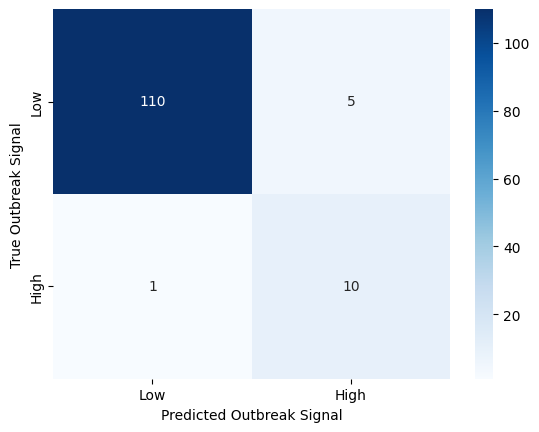

In [753]:
cf=metrics.confusion_matrix(classification_set['label'],classification_set['pred'])
sns.heatmap(cf,annot=True, fmt='d',cmap='Blues',xticklabels=['Low','High'],yticklabels=['Low','High'])
plt.ylabel("True Outbreak Signal")
plt.xlabel("Predicted Outbreak Signal")
plt.show()

ROC-AUC Score: 0.974703557312253


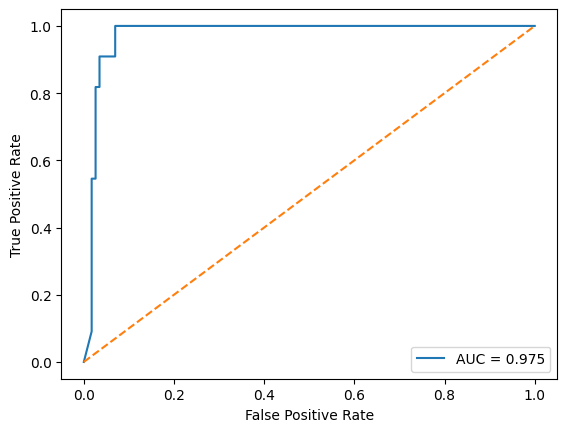

In [754]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]  # probability of class 1
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Predicting Medicine Required

In [755]:
# --- FEATURES / TARGET ---
features = ["lag_1", "lag_2", "rolling_avg_2", "rolling_max_2", 
            "week_of_year", "inpatient_ratio", "in_care_rate", 
            "recovery_rate", "high_risk_age_ratio"]
target = "case_count"

X_train = train_set[features]
y_train = train_set[target]

X_test = test_set[features]
y_test = test_set[target]
X_train.head()

,lag_1,lag_2,rolling_avg_2,rolling_max_2,week_of_year,inpatient_ratio,in_care_rate,recovery_rate,high_risk_age_ratio
0,0.0,0.0,0.0,0.0,1,0.263158,0.263158,0.000000,0.236842
1,38.0,0.0,19.0,38.0,2,0.164179,0.179104,0.059701,0.268657
2,67.0,38.0,52.5,67.0,3,0.232323,0.212121,0.000000,0.303030
3,99.0,67.0,83.0,99.0,4,0.172840,0.172840,0.049383,0.246914
4,81.0,99.0,90.0,99.0,5,0.233766,0.168831,0.000000,0.272727


In [756]:
# --- MODEL ---
model = RandomForestRegressor(n_estimators=100, max_depth=5, criterion='absolute_error',random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'absolute_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [757]:
# --- EVALUATION ---
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE: ", mse)
print("Train R2:", r2_score(y_train, model.predict(X_train)))
print("Test R2: ", r2)
print("Gap:      ", round(r2_score(y_train, model.predict(X_train))- r2, 4))
case_count_set = test_set.copy()
case_count_set['pred'] = y_pred
print(case_count_set[['district', 'week', 'pred', 'case_count']])

MAE: 15.770357142857145
MSE:  499.57776805555545
Train R2: 0.8912465645879288
Test R2:  0.22273958362998525
Gap:       0.6685
      district  week    pred  case_count
11    bang_bon    12  40.000          32
12    bang_bon    13  37.555          30
13    bang_bon    14  30.070           3
25   bang_kapi    12  63.895          51
26   bang_kapi    13  55.555          51
..         ...   ...     ...         ...
660   watthana    12  99.620          89
661   watthana    13  93.745           8
673   yan_nawa    12  32.915          29
674   yan_nawa    13  30.595          21
675   yan_nawa    14  23.900           3

[126 rows x 4 columns]


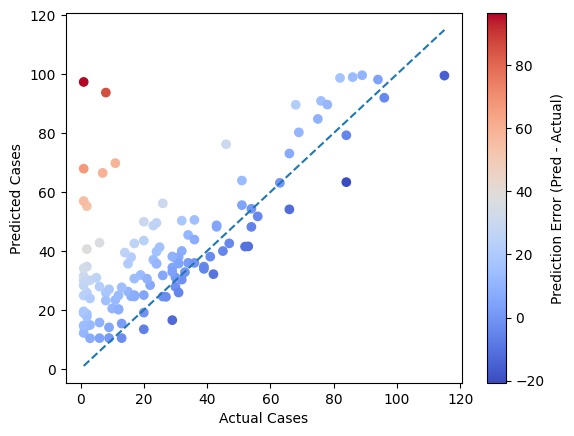

In [758]:
error = y_pred - y_test

plt.scatter(y_test, y_pred, c=error, cmap="coolwarm")
plt.colorbar(label="Prediction Error (Pred - Actual)")

plt.xlabel("Actual Cases")
plt.ylabel("Predicted Cases")
# plt.title("Actual vs Predicted (Colored by Error)")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.show()

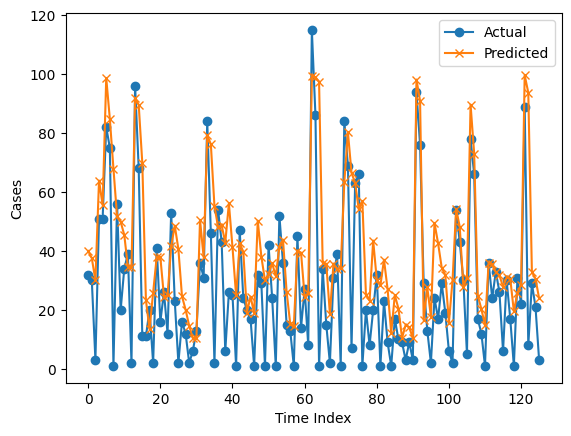

In [759]:
plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')

plt.xlabel("Time Index")
plt.ylabel("Cases")
# plt.title("Actual vs Predicted Over Time")

plt.legend()
plt.show()

## Visualization Bangkok

In [760]:
inverse_mapping = {v: k for k, v in district_mapping.items()}

latest_classification = classification_set.sort_values("week").groupby("district").tail(1)
latest_case_count = case_count_set.sort_values("week").groupby("district").tail(1)
# Then apply to your prediction output
latest_classification['district_thai'] = latest_classification['district'].map(inverse_mapping)
latest_classification['district_thai'] = 'เขต' + latest_classification['district_thai']
latest_case_count['district_thai'] = latest_case_count['district'].map(inverse_mapping)
latest_case_count['district_thai'] = 'เขต' + latest_case_count['district_thai']

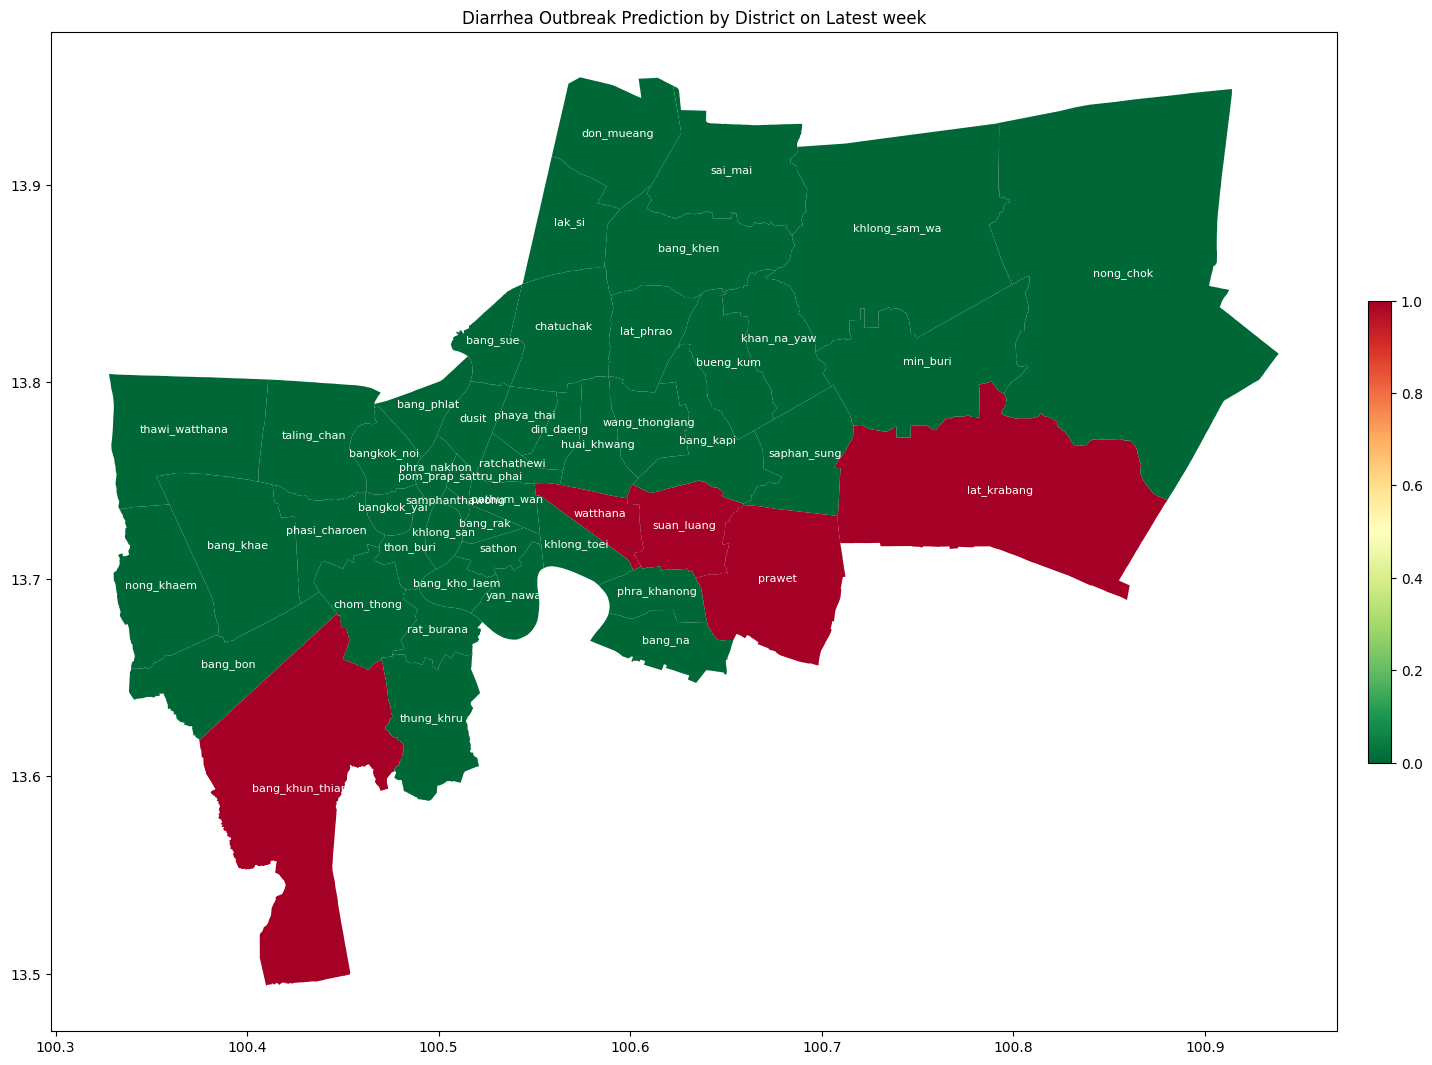

In [761]:
# Classification set
import folium
import geopandas as gpd
import json
import matplotlib.font_manager as fm
thai_font = fm.FontProperties(fname=r"C:\Windows\Fonts\CordiaUPC.ttf")
# 1. Load Bangkok district boundaries
gdf = gpd.read_file("Bangkok-districts.geojson")
# 2. Merge predictions with geometry
#    CRITICAL: district names must match exactly between
#    your prediction output and the GeoJSON file
# Fix 1: Set correct CRS if missing
if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")
else:
    gdf = gdf.to_crs("EPSG:4326")

# Redo merge after CRS fix
merged = gdf.merge(latest_classification,
                   left_on="dname",
                   right_on="district_thai",
                   how="left")

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
merged.plot(
    column="pred",
    cmap="RdYlGn_r",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    legend_kwds={
        "shrink": 0.3,      
        "pad": 0.02       
    }
)

# Add district name labels at centroid of each district
for idx, row in merged.iterrows():
    centroid = row.geometry.centroid
    thai_name = row["dname"].replace("เขต", "").strip()
    ax.annotate(
        text=district_mapping.get(thai_name, thai_name),
        xy=(centroid.x, centroid.y),
        ha="center",
        fontsize=8,        # small enough to fit inside districts
        color="white",
    )

ax.set_title("Diarrhea Outbreak Prediction by District on Latest week")
plt.show()

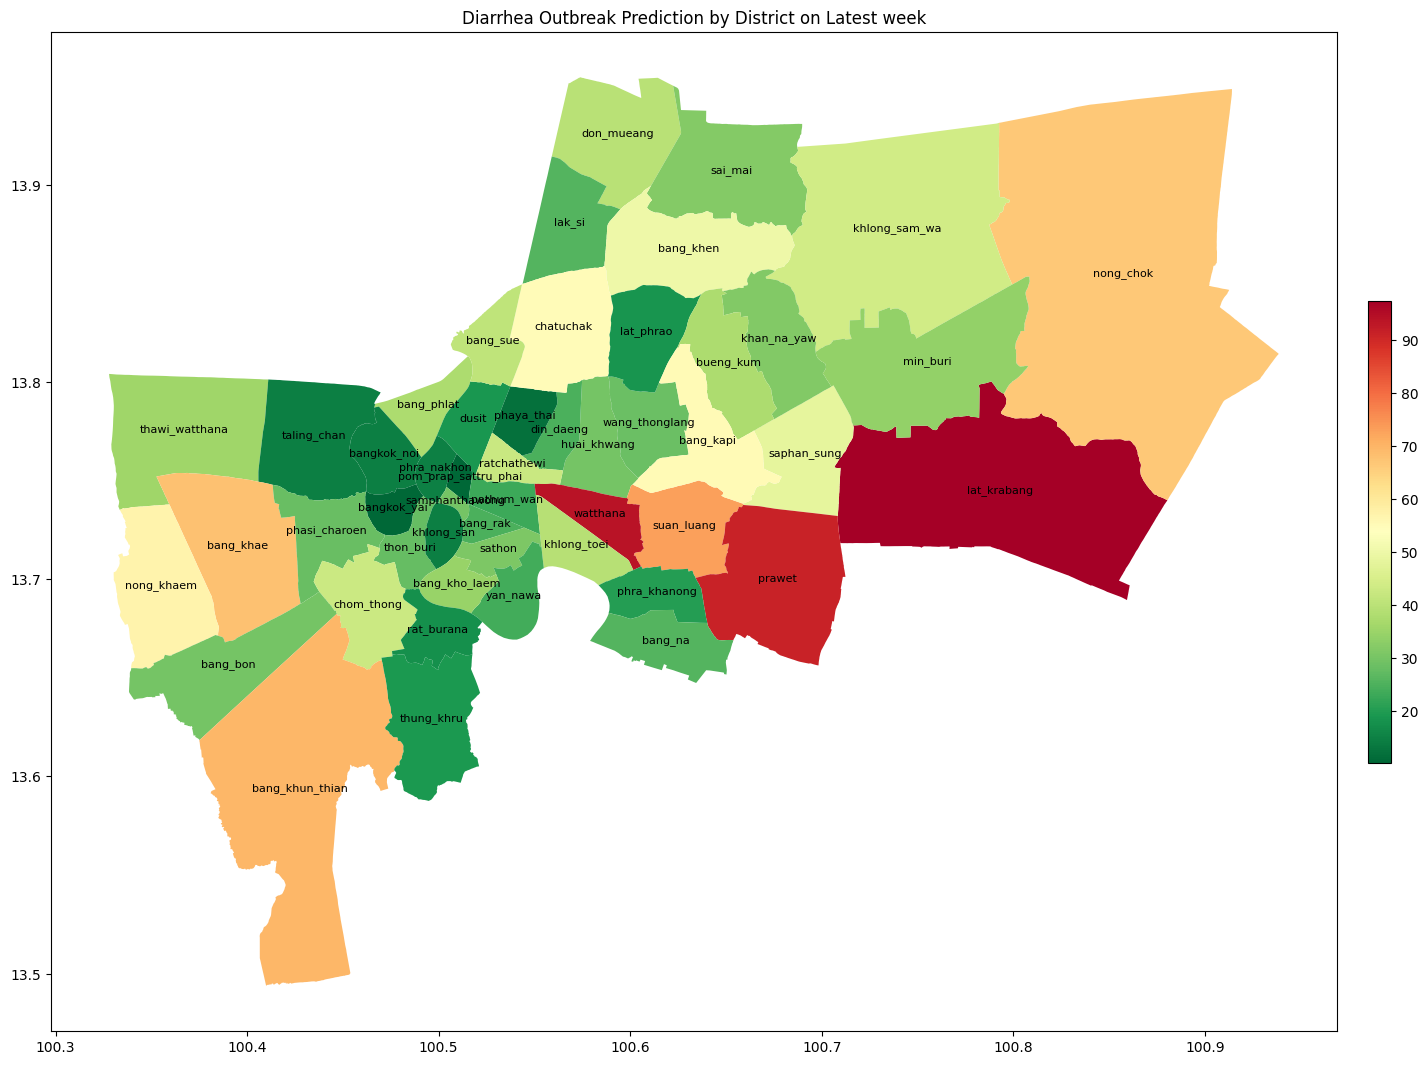

In [762]:
# Classification set
import folium
import geopandas as gpd
import json
import matplotlib.font_manager as fm
thai_font = fm.FontProperties(fname=r"C:\Windows\Fonts\CordiaUPC.ttf")
# 1. Load Bangkok district boundaries
gdf = gpd.read_file("Bangkok-districts.geojson")
# 2. Merge predictions with geometry
#    CRITICAL: district names must match exactly between
#    your prediction output and the GeoJSON file
# Fix 1: Set correct CRS if missing
if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")
else:
    gdf = gdf.to_crs("EPSG:4326")

# Redo merge after CRS fix
merged = gdf.merge(latest_case_count,
                   left_on="dname",
                   right_on="district_thai",
                   how="left")

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
merged.plot(
    column="pred",
    cmap="RdYlGn_r",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    legend_kwds={
        "shrink": 0.3,      
        "pad": 0.02       
    }
)

# Add district name labels at centroid of each district
for idx, row in merged.iterrows():
    centroid = row.geometry.centroid
    thai_name = row["dname"].replace("เขต", "").strip()
    ax.annotate(
        text=district_mapping.get(thai_name, thai_name),
        xy=(centroid.x, centroid.y),
        ha="center",
        fontsize=8,        # small enough to fit inside districts
        color="black",
    )

ax.set_title("Diarrhea Outbreak Prediction by District on Latest week")
plt.show()